In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, f1_score, 
    classification_report, confusion_matrix, roc_auc_score
)

# Load model and feature names
with open("../models/xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../models/feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

print("✅ Model loaded")
print(f"Features: {len(feature_names)}")

✅ Model loaded
Features: 33


In [4]:
# Load feature engineered data
df = pd.read_csv("../data/upi_features.csv")

# Features aur target alag karo
X = df[feature_names]
y = df["is_failed"]

print(f"Total samples: {len(df)}")
print(f"Failure rate: {y.mean():.2%}")

# Probability predictions
y_proba = model.predict_proba(X)[:, 1]
print(f"\nPrediction probabilities sample: {y_proba[:5].round(3)}")
print(f"AUC-ROC: {roc_auc_score(y, y_proba):.4f}")

Total samples: 500000
Failure rate: 29.27%

Prediction probabilities sample: [0.248 0.103 0.361 0.551 0.43 ]
AUC-ROC: 0.6323


Default threshold (0.5):
  F1: 0.3106
  Failures caught: 35611 / 146350

Best threshold: 0.2782
  F1: 0.4827
  Failures caught: 117576 / 146350


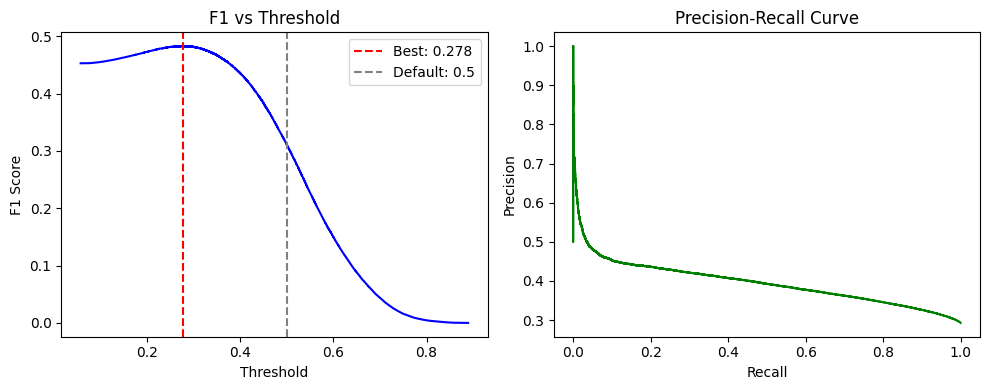

✅ Plot saved


In [5]:
# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y, y_proba)

# F1 score har threshold pe
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

# Best threshold — max F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Default threshold (0.5):")
y_pred_default = (y_proba >= 0.5).astype(int)
print(f"  F1: {f1_score(y, y_pred_default):.4f}")
print(f"  Failures caught: {y_pred_default[y==1].sum()} / {y.sum()}")

print(f"\nBest threshold: {best_threshold:.4f}")
print(f"  F1: {best_f1:.4f}")
y_pred_best = (y_proba >= best_threshold).astype(int)
print(f"  Failures caught: {y_pred_best[y==1].sum()} / {y.sum()}")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, color='blue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best: {best_threshold:.3f}')
plt.axvline(0.5, color='gray', linestyle='--', label='Default: 0.5')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recalls[:-1], precisions[:-1], color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig("../notebooks/threshold_analysis.png", dpi=120)
plt.show()
print("✅ Plot saved")

In [7]:
print("Classification Report (threshold = 0.2782):\n")
print(classification_report(y, y_pred_best, target_names=["Success", "Failure"]))

# Save threshold
import json
threshold_config = {"optimal_threshold": float(best_threshold)}
with open("../models/threshold_config.json", "w") as f:
    json.dump(threshold_config, f)

print(f"✅ Threshold saved: ../models/threshold_config.json")

Classification Report (threshold = 0.2782):

              precision    recall  f1-score   support

     Success       0.82      0.37      0.51    353650
     Failure       0.34      0.80      0.48    146350

    accuracy                           0.50    500000
   macro avg       0.58      0.59      0.50    500000
weighted avg       0.68      0.50      0.50    500000

✅ Threshold saved: ../models/threshold_config.json
